# K-space INR pipeline: residual INR and NeRP-style reconstruction

This notebook reconstructs one real SLAM follow-up slice from multi-coil Cartesian k-space. It is organized so that each conceptual stage can be inspected independently:

1. Load the registered, DICOM-derived prior magnitude image and follow-up k-space.
2. Fit a prior INR to the prior image.
3. Fit a current-only complex INR from k-space, without a patient prior.
4. Freeze the prior INR and fit the original complex residual INR.
5. Fit the phase-aware variation: sparse scalar magnitude change plus an independent phase INR.
6. Optionally run a NeRP-style baseline by fitting one complex INR to the prior and then fine-tuning all of its weights from k-space.
7. Plot reconstructions, signed longitudinal changes, magnitude errors, losses, and metrics.

The local SLAM release does not contain raw `.dcm` files. `prior.npy` is the already registered magnitude image derived from the prior DICOM exam, so this is the correct image to embed. The native k-space matrix is smaller than the stored 256×256 reference; we use exact center-cropping/padding and never interpolation.

## Notebook environment

A dedicated `presinr-notebook` environment is used for this notebook. To reproduce it from the working `presinr` environment, run these commands once from the repository root:

```bash
conda create -y -n presinr-notebook --clone presinr
conda run -n presinr-notebook python -m pip install -e '.[notebook]'
conda run -n presinr-notebook python -m ipykernel install --user --name presinr-notebook --display-name 'Python (presinr-notebook)'
```

Then select `Python (presinr-notebook)` in the IDE. The reconstruction code itself does not depend on Jupyter; `ipykernel` is therefore kept as an optional project dependency.

## What differs between the two methods?

Let $A(x)=MFSx$ denote the masked multi-coil MRI forward operator.

**Residual INR (ours)** first fits $f_{\theta_p}(c)\approx x_{prior}(c)$, freezes $\theta_p$, and then optimizes a new complex residual field:

$$\hat x(c)=f_{\theta_p}(c)+r_{\phi,R}(c)+i\,r_{\phi,I}(c),$$
$$\min_\phi \|A(\hat x)-y\|_2^2+\lambda_r\|r_\phi\|_1.$$

**Magnitude–phase residual (new variation)** keeps the DICOM-derived prior and longitudinal change in magnitude space while learning acquisition phase independently:

$$\hat x(c)=\max(f_{\theta_p}(c)+\Delta m_\eta(c),0)\,e^{i\varphi_\psi(c)},$$
$$\min_{\eta,\psi} \|A(\hat x)-y\|_2^2+\lambda_m\|\Delta m_\eta\|_1+\lambda_\varphi TV_{circ}(\varphi_\psi).$$

Only the scalar magnitude change is encouraged to be sparse. The phase INR is initialized from a smoothed zero-filled follow-up phase and uses a wrap-invariant circular smoothness term.

**Current-only INR** is a randomly initialized real/imaginary INR optimized from the same k-space loss. It uses no patient prior and determines whether improvement comes from longitudinal information or simply from the INR parameterization.

**NeRP-style** uses one network. Its weights are first optimized to represent the prior, and those same weights are then all fine-tuned using only measurement consistency:

$$\theta_0=\arg\min_\theta \|f_\theta-x_{prior}\|_2^2,$$
$$\theta^*=\arg\min_{\theta\leftarrow\theta_0} \|A(f_\theta)-y\|_2^2.$$

The original NeRP MRI experiment used a real image and radial NUFFT. For the real SLAM data here, the baseline is explicitly a **NeRP-style complex, multi-coil Cartesian adaptation**: the network has real/imaginary outputs, embeds the magnitude prior with zero initial phase, and learns phase during k-space fine-tuning.

In [32]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.ndimage import gaussian_filter

# Work whether the notebook is launched from the repository root or notebooks/.
REPO = Path.cwd().resolve()
if not (REPO / 'src' / 'presinr').exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / 'src'))

from presinr.data.slam import SlamTestSlices
from presinr.forward import CartesianSense
from presinr.losses import data_consistency
from presinr.metrics import all_metrics
from presinr.models import PriorMagnitudePhaseINR, PriorResidualINR, build_inr
from presinr.models.inr import make_coord_grid
from presinr.recon import (
    KspaceFitConfig, MagnitudePhaseFitConfig, PhaseFitConfig,
    PriorFitConfig, ResidualFitConfig, fit_current_only,
    fit_magnitude_phase_residual, fit_phase_inr, fit_prior, fit_residual,
)
from presinr.utils import center_pad_to, get_device, set_seed, to_numpy

print('repository:', REPO)
print('torch:', torch.__version__, '| CUDA available:', torch.cuda.is_available())

repository: /home/omarg/Patient-Specific-Residual-INR
torch: 2.5.1+cu121 | CUDA available: True


In [33]:
# Experiment controls. QUICK_RUN is for reviewing the pipeline; use False for results.
SEED = 0
SAMPLE_INDEX = 20
MIDDLE_ONLY = False  # If True, only reconstruct the middle slice of the volume.
QUICK_RUN = False
RUN_CURRENT_ONLY = True
RUN_MAGNITUDE_PHASE = True
RUN_NERP = True

# The environment flag is used only by the automated smoke test.
SMOKE_TEST = os.getenv('PRESINR_NOTEBOOK_SMOKE', '0') == '1'
if SMOKE_TEST:
    PRIOR_ITERS = RESIDUAL_ITERS = CURRENT_ONLY_ITERS = 1
    PHASE_INIT_ITERS = MAGNITUDE_PHASE_ITERS = 1
    NERP_PRIOR_ITERS = NERP_KSPACE_ITERS = 1
elif QUICK_RUN:
    PRIOR_ITERS, RESIDUAL_ITERS, CURRENT_ONLY_ITERS = 250, 300, 300
    PHASE_INIT_ITERS, MAGNITUDE_PHASE_ITERS = 250, 300
    NERP_PRIOR_ITERS, NERP_KSPACE_ITERS = 250, 300
else:
    PRIOR_ITERS, RESIDUAL_ITERS, CURRENT_ONLY_ITERS = 3000, 3000, 3000
    PHASE_INIT_ITERS, MAGNITUDE_PHASE_ITERS = 1000, 3000
    # NeRP reports 1000 iterations for each 2-D stage.
    NERP_PRIOR_ITERS, NERP_KSPACE_ITERS = 1000, 1000

LAMBDA_RESIDUAL = 1e-3
LAMBDA_MAGNITUDE_CHANGE = 1e-3
LAMBDA_PHASE_TV = 1e-5
set_seed(SEED)
device = get_device()
print('device:', device)
print('iterations:', {
    'prior': PRIOR_ITERS, 'current-only': CURRENT_ONLY_ITERS,
    'complex residual': RESIDUAL_ITERS, 'phase init': PHASE_INIT_ITERS,
    'magnitude-phase': MAGNITUDE_PHASE_ITERS,
    'NeRP prior': NERP_PRIOR_ITERS, 'NeRP k-space': NERP_KSPACE_ITERS,
})

device: cuda
iterations: {'prior': 3000, 'current-only': 3000, 'complex residual': 3000, 'phase init': 1000, 'magnitude-phase': 3000, 'NeRP prior': 1000, 'NeRP k-space': 1000}


## 1. Load one SLAM slice and construct $A=MFS$

`ksp` and the coil sensitivity maps live on the native acquisition grid. The reference and registered prior are stored on a center-padded 256×256 grid. Model fitting happens on the native grid; final images are padded back only for visualization and evaluation.

In [34]:
dataset = SlamTestSlices(data_dir=REPO / 'data', middle_only=MIDDLE_ONLY, normalize=True)
sample = dataset[SAMPLE_INDEX]

ksp = sample['ksp'].to(device)
mps = sample['mps'].to(device)
mask = sample['mask'].to(device)
prior_native = sample['prior_native'].to(device)
reference_native = sample['recon_native'].to(device)
prior_full = sample['prior'].to(device)
reference_full = sample['recon'].to(device)

H, W = sample['native_shape']
stored_shape = sample['stored_shape']
operator = CartesianSense(mps, mask).to(device)
zero_filled_native = operator.zero_filled(ksp)
zero_filled_full = center_pad_to(zero_filled_native, stored_shape)
acceleration = mask.numel() / float(mask.sum())

print(f'slices available: {len(dataset)}')
print(f'native grid: {(H, W)} | stored grid: {stored_shape} | coils: {mps.shape[0]}')
print(f'measured mask fraction: {float(mask.mean()):.4f} | nominal R: {acceleration:.2f}')
print(f'change extent: {sample["change_extent"]} | k-space scale: {sample["ksp_scale"]:.4g}')

slices available: 60
native grid: (256, 206) | stored grid: (256, 256) | coils: 10
measured mask fraction: 0.5583 | nominal R: 1.79
change extent: 0 | k-space scale: 4.336e+06


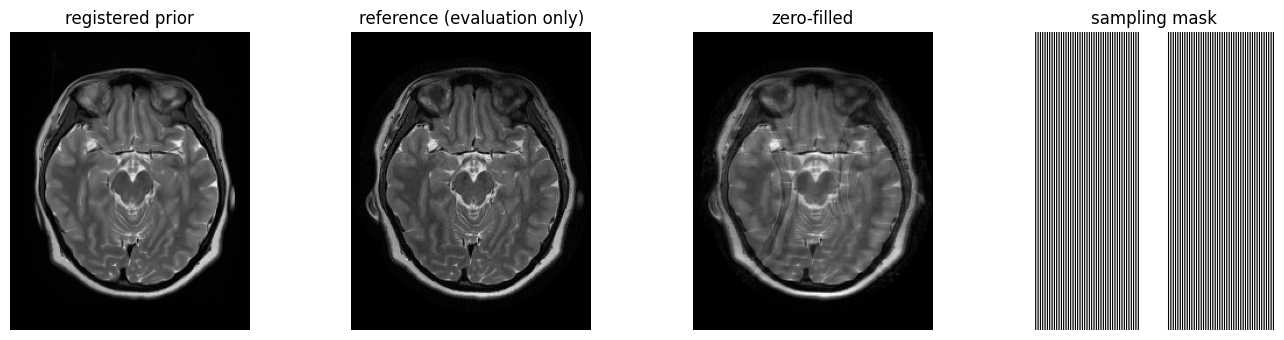

In [35]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, image, title in zip(
    axes,
    [prior_native, reference_native, zero_filled_native, mask],
    ['registered prior', 'reference (evaluation only)', 'zero-filled', 'sampling mask'],
):
    array = to_numpy(image)
    if title == 'sampling mask':
        ax.imshow(array, cmap='gray', vmin=0, vmax=1)
    else:
        ax.imshow(np.abs(array), cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 2. Current-only complex INR baseline

This baseline is randomly initialized and fitted only to measured follow-up k-space. It receives neither the prior image nor the evaluation reference.

In [36]:
recon_current_only_full = None
current_only_result = None
if RUN_CURRENT_ONLY:
    set_seed(SEED + 2)
    current_only_inr = build_inr(
        'siren', out_features=2, hidden_features=256, hidden_layers=4
    ).to(device)
    current_only_result = fit_current_only(
        current_only_inr, operator, ksp, (H, W),
        KspaceFitConfig(
            iters=CURRENT_ONLY_ITERS, lr=1e-3,
            log_every=max(1, CURRENT_ONLY_ITERS // 5),
        ),
        device=device,
    )
    recon_current_only_full = center_pad_to(current_only_result.recon, stored_shape)
    print('final current-only data consistency:', current_only_result.history['dc'][-1])

[current-only] iter     0  dc=0.015964
[current-only] iter   600  dc=0.000139
[current-only] iter  1200  dc=0.000140
[current-only] iter  1800  dc=0.000139
[current-only] iter  2400  dc=0.011143
[current-only] iter  2999  dc=0.011142
final current-only data consistency: 0.011141878552734852


## 3. Fit the prior INR

This cell sees the registered prior image but never the follow-up reference. It maps normalized coordinates to one magnitude value. The resulting network is frozen before fitting the residual.

In [37]:
set_seed(SEED)
prior_inr = build_inr(
    'siren', out_features=1, hidden_features=256, hidden_layers=4
).to(device)
prior_history = fit_prior(
    prior_inr,
    prior_native,
    PriorFitConfig(iters=PRIOR_ITERS, lr=1e-4, log_every=max(1, PRIOR_ITERS // 5)),
    device=device,
)

coords = make_coord_grid(H, W, device=device)
with torch.no_grad():
    prior_fit_native = prior_inr(coords)[..., 0].reshape(H, W)
prior_fit_full = center_pad_to(prior_fit_native, stored_shape)

[prior] iter     0  L1=0.21067
[prior] iter   600  L1=0.00792
[prior] iter  1200  L1=0.00459
[prior] iter  1800  L1=0.00355
[prior] iter  2400  L1=0.00296
[prior] iter  2999  L1=0.00263


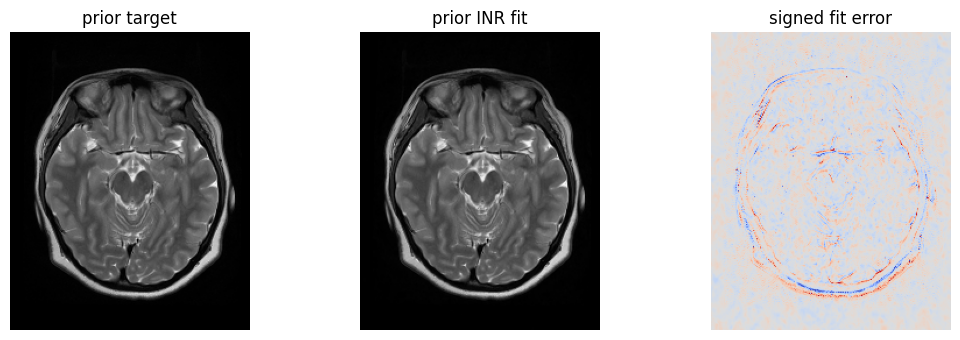

final prior L1: 0.0026286847423762083


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
prior_error = prior_fit_native - prior_native
views = [prior_native, prior_fit_native, prior_error]
titles = ['prior target', 'prior INR fit', 'signed fit error']
for i, (ax, image, title) in enumerate(zip(axes, views, titles)):
    array = to_numpy(image)
    if i == 2:
        limit = np.quantile(np.abs(array), 0.999) + 1e-8
        ax.imshow(array, cmap='coolwarm', vmin=-limit, vmax=limit)
    else:
        ax.imshow(np.abs(array), cmap='gray', vmin=0)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()
print('final prior L1:', prior_history['loss'][-1])

## 4. Freeze the prior and fit the complex residual from k-space

The follow-up reference is not passed to this optimizer. The residual network produces real and imaginary channels; the SENSE operator maps their composition with the frozen prior to predicted coil k-space.

In [39]:
set_seed(SEED + 1)
residual_inr = build_inr(
    'siren', out_features=2, hidden_features=128, hidden_layers=4
).to(device)
residual_model = PriorResidualINR(prior_inr, residual_inr).to(device)
residual_result = fit_residual(
    residual_model,
    operator,
    ksp,
    (H, W),
    ResidualFitConfig(
        iters=RESIDUAL_ITERS,
        lr=1e-3,
        lambda_res=LAMBDA_RESIDUAL,
        log_every=max(1, RESIDUAL_ITERS // 5),
    ),
    device=device,
)
recon_residual_native = residual_result.recon
recon_residual_full = center_pad_to(recon_residual_native, stored_shape)
effective_residual = residual_result.history['effective_residual_map']
print('final residual data consistency:', residual_result.history['dc'][-1])

[resid] iter     0  loss=0.037114  dc=0.037073
[resid] iter   600  loss=0.000485  dc=0.000185
[resid] iter  1200  loss=0.000478  dc=0.000175
[resid] iter  1800  loss=0.000466  dc=0.000165
[resid] iter  2400  loss=0.000502  dc=0.000194
[resid] iter  2999  loss=0.000541  dc=0.000226
final residual data consistency: 0.00022633702610619366


## 5. Magnitude–phase residual variation

This variation freezes the same prior magnitude INR, learns a scalar magnitude change, and learns phase in a separate INR. Phase is initialized from a Gaussian-smoothed zero-filled complex image; low-magnitude pixels receive little phase-initialization weight. Only magnitude change receives the sparsity penalty.

In [40]:
recon_magnitude_phase_full = None
magnitude_phase_result = None
phase_init_history = None
if RUN_MAGNITUDE_PHASE:
    # Smooth the complex adjoint before extracting phase to reduce alias/noise.
    zf_array = to_numpy(zero_filled_native)
    zf_smooth = (
        gaussian_filter(zf_array.real, sigma=2.0)
        + 1j * gaussian_filter(zf_array.imag, sigma=2.0)
    )
    phase_target = torch.from_numpy(np.angle(zf_smooth).astype(np.float32)).to(device)
    phase_weight = zero_filled_native.abs()
    phase_weight = (
        phase_weight / (torch.quantile(phase_weight.reshape(-1), 0.99) + 1e-8)
    ).clamp(0.0, 1.0)

    set_seed(SEED + 3)
    magnitude_change_inr = build_inr(
        'siren', out_features=1, hidden_features=128, hidden_layers=4
    ).to(device)
    phase_inr = build_inr(
        'siren', out_features=1, hidden_features=64, hidden_layers=3
    ).to(device)
    phase_init_history = fit_phase_inr(
        phase_inr, phase_target, weights=phase_weight,
        cfg=PhaseFitConfig(
            iters=PHASE_INIT_ITERS, lr=1e-4,
            log_every=max(1, PHASE_INIT_ITERS // 5),
        ),
        device=device,
    )
    magnitude_phase_model = PriorMagnitudePhaseINR(
        prior_inr, magnitude_change_inr, phase_inr
    ).to(device)
    magnitude_phase_result = fit_magnitude_phase_residual(
        magnitude_phase_model, operator, ksp, (H, W),
        MagnitudePhaseFitConfig(
            iters=MAGNITUDE_PHASE_ITERS, lr=1e-3, phase_lr=3e-4,
            lambda_change=LAMBDA_MAGNITUDE_CHANGE,
            lambda_phase_tv=LAMBDA_PHASE_TV,
            log_every=max(1, MAGNITUDE_PHASE_ITERS // 5),
        ),
        device=device,
    )
    recon_magnitude_phase_full = center_pad_to(
        magnitude_phase_result.recon, stored_shape
    )
    print(
        'final magnitude-phase data consistency:',
        magnitude_phase_result.history['dc'][-1],
    )

[phase-init] iter     0  circular=1.126388
[phase-init] iter   200  circular=0.207979
[phase-init] iter   400  circular=0.053057
[phase-init] iter   600  circular=0.017073
[phase-init] iter   800  circular=0.008103
[phase-init] iter   999  circular=0.004804
[mag-phase] iter     0  loss=0.001052  dc=0.001029
[mag-phase] iter   600  loss=0.000249  dc=0.000206
[mag-phase] iter  1200  loss=0.000213  dc=0.000174
[mag-phase] iter  1800  loss=0.000213  dc=0.000175
[mag-phase] iter  2400  loss=0.000209  dc=0.000170
[mag-phase] iter  2999  loss=0.000207  dc=0.000169
final magnitude-phase data consistency: 0.00016865090583451092


## 6. NeRP-style k-space baseline (optional)

NeRP does **not** keep a frozen prior branch and does not add a residual branch. The first cell below embeds the prior into a two-channel INR. The second cell fine-tunes every parameter of that same INR against measured k-space. This makes it easy to see the central comparison: weight initialization from the prior versus an explicit frozen-prior decomposition.

For a paper-scale NeRP reproduction, the published method used Fourier feature size 256, a periodic MLP of width 512 for MRI, radial NUFFT, and L2 losses. Here we retain this project’s SIREN backbone and SLAM’s Cartesian multi-coil forward operator so that the baseline differs mainly in how it uses the longitudinal prior.

In [41]:
nerp_prior_history = []
nerp_kspace_history = []
recon_nerp_native = None

if RUN_NERP:
    set_seed(SEED)
    nerp_inr = build_inr(
        'siren', out_features=2, hidden_features=256, hidden_layers=4
    ).to(device)
    prior_target_ri = torch.stack(
        [prior_native.reshape(-1), torch.zeros(H * W, device=device)], dim=-1
    )
    optimizer = torch.optim.Adam(nerp_inr.parameters(), lr=1e-4)
    for iteration in range(NERP_PRIOR_ITERS):
        optimizer.zero_grad(set_to_none=True)
        prediction_ri = nerp_inr(coords)
        loss = (prediction_ri - prior_target_ri).pow(2).mean()
        loss.backward()
        optimizer.step()
        nerp_prior_history.append(float(loss.detach()))
        if iteration % max(1, NERP_PRIOR_ITERS // 5) == 0 or iteration == NERP_PRIOR_ITERS - 1:
            print(f'[NeRP prior] iter {iteration:5d}  MSE={loss.item():.6f}')
else:
    nerp_inr = None

[NeRP prior] iter     0  MSE=0.049698
[NeRP prior] iter   200  MSE=0.000329
[NeRP prior] iter   400  MSE=0.000124
[NeRP prior] iter   600  MSE=0.000055
[NeRP prior] iter   800  MSE=0.000030
[NeRP prior] iter   999  MSE=0.000017


In [42]:
if RUN_NERP:
    # All prior-embedded parameters remain trainable: this is the NeRP step.
    optimizer = torch.optim.Adam(nerp_inr.parameters(), lr=1e-5)
    for iteration in range(NERP_KSPACE_ITERS):
        optimizer.zero_grad(set_to_none=True)
        prediction_ri = nerp_inr(coords)
        image = torch.complex(prediction_ri[..., 0], prediction_ri[..., 1]).reshape(H, W)
        predicted_ksp = operator(image)
        loss = data_consistency(predicted_ksp, ksp, mask=operator.mask)
        loss.backward()
        optimizer.step()
        nerp_kspace_history.append(float(loss.detach()))
        if iteration % max(1, NERP_KSPACE_ITERS // 5) == 0 or iteration == NERP_KSPACE_ITERS - 1:
            print(f'[NeRP k-space] iter {iteration:5d}  DC={loss.item():.6f}')
    with torch.no_grad():
        prediction_ri = nerp_inr(coords)
        recon_nerp_native = torch.complex(
            prediction_ri[..., 0], prediction_ri[..., 1]
        ).reshape(H, W)
    recon_nerp_full = center_pad_to(recon_nerp_native, stored_shape)
else:
    recon_nerp_full = None

[NeRP k-space] iter     0  DC=0.036506
[NeRP k-space] iter   200  DC=0.002716
[NeRP k-space] iter   400  DC=0.000671
[NeRP k-space] iter   600  DC=0.000424
[NeRP k-space] iter   800  DC=0.000332
[NeRP k-space] iter   999  DC=0.000285


## 7. Plot reconstructions, longitudinal changes, and magnitude error

Magnitude images are shown in gray. Change maps are signed magnitude differences relative to the registered prior and use one shared symmetric color range. The final panel reports the absolute magnitude-image error $\left||\hat{x}|-|x_{ref}|\right|$ with one shared scale across methods.

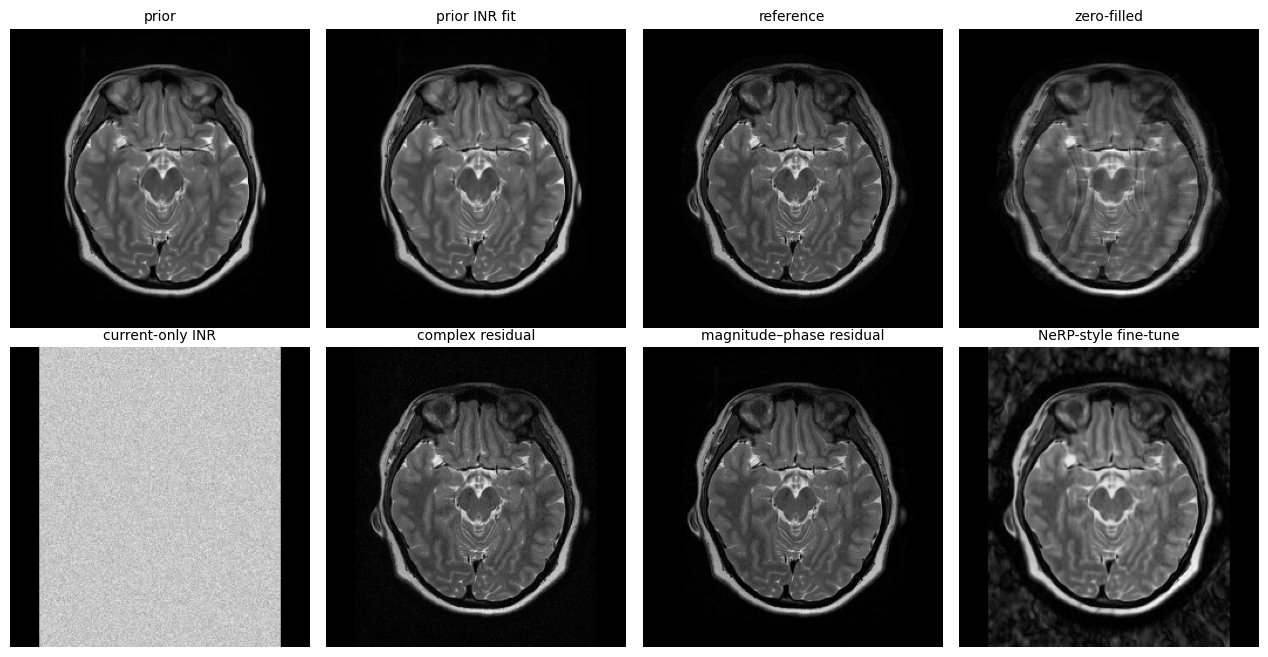

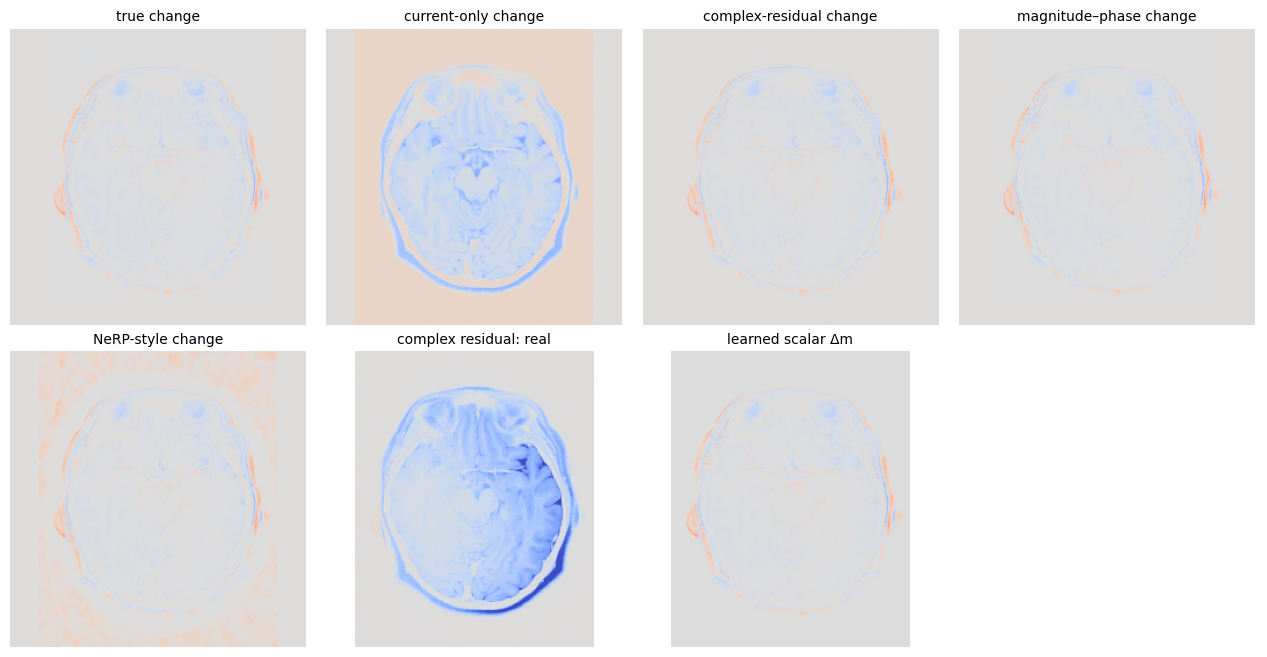

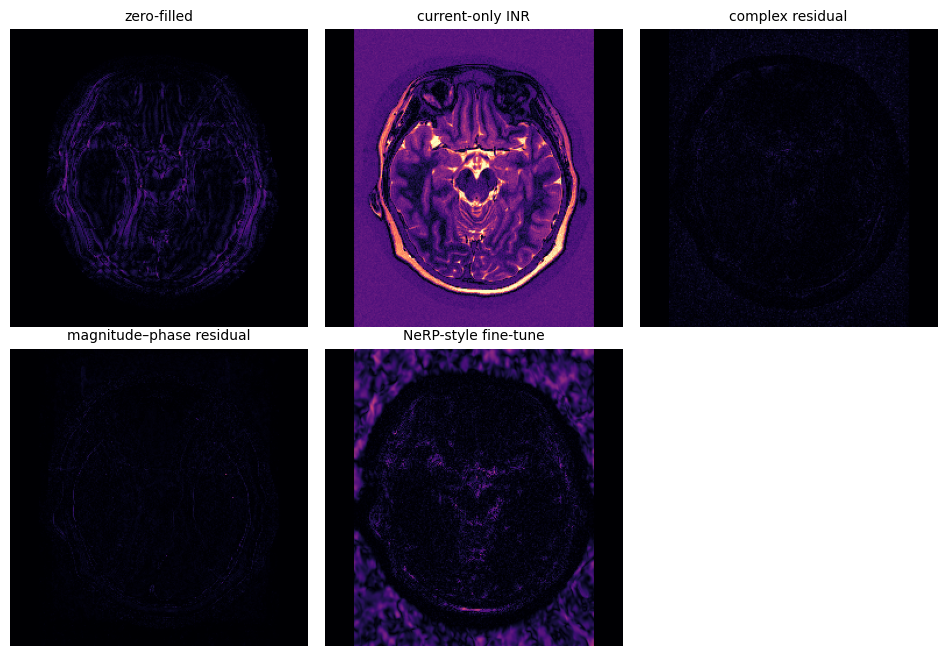

In [43]:
def show_grid(items, ncols=4, cmap='gray', vmin=None, vmax=None, figsize_scale=3.2):
    nrows = int(np.ceil(len(items) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_scale * ncols, 3.3 * nrows))
    axes = np.atleast_1d(axes).reshape(-1)
    for ax, (title, array) in zip(axes, items):
        ax.imshow(array, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    for ax in axes[len(items):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

image_items = [
    ('prior', np.abs(to_numpy(prior_full))),
    ('prior INR fit', np.abs(to_numpy(prior_fit_full))),
    ('reference', np.abs(to_numpy(reference_full))),
    ('zero-filled', np.abs(to_numpy(zero_filled_full))),
]
if recon_current_only_full is not None:
    image_items.append(('current-only INR', np.abs(to_numpy(recon_current_only_full))))
image_items.append(('complex residual', np.abs(to_numpy(recon_residual_full))))
if recon_magnitude_phase_full is not None:
    image_items.append(('magnitude–phase residual', np.abs(to_numpy(recon_magnitude_phase_full))))
if recon_nerp_full is not None:
    image_items.append(('NeRP-style fine-tune', np.abs(to_numpy(recon_nerp_full))))
show_grid(image_items, ncols=4, cmap='gray', vmin=0)

prior_magnitude = np.abs(to_numpy(prior_full))
true_change = np.abs(to_numpy(reference_full)) - prior_magnitude
change_items = [('true change', true_change)]
if recon_current_only_full is not None:
    change_items.append(('current-only change', np.abs(to_numpy(recon_current_only_full)) - prior_magnitude))
change_items.append(('complex-residual change', np.abs(to_numpy(recon_residual_full)) - prior_magnitude))
if recon_magnitude_phase_full is not None:
    change_items.append(('magnitude–phase change', np.abs(to_numpy(recon_magnitude_phase_full)) - prior_magnitude))
if recon_nerp_full is not None:
    change_items.append(('NeRP-style change', np.abs(to_numpy(recon_nerp_full)) - prior_magnitude))
change_items.append(('complex residual: real', to_numpy(effective_residual[..., 0])))
if magnitude_phase_result is not None:
    change_items.append(('learned scalar Δm', to_numpy(magnitude_phase_result.magnitude_residual)))
signed_limit = max(np.quantile(np.abs(array), 0.995) for _, array in change_items) + 1e-8
show_grid(change_items, ncols=4, cmap='coolwarm', vmin=-signed_limit, vmax=signed_limit)

# Absolute magnitude-image error, matching the magnitude fidelity metrics.
reference_magnitude = np.abs(to_numpy(reference_full))
error_sources = [('zero-filled', zero_filled_full)]
if recon_current_only_full is not None:
    error_sources.append(('current-only INR', recon_current_only_full))
error_sources.append(('complex residual', recon_residual_full))
if recon_magnitude_phase_full is not None:
    error_sources.append(('magnitude–phase residual', recon_magnitude_phase_full))
if recon_nerp_full is not None:
    error_sources.append(('NeRP-style fine-tune', recon_nerp_full))
error_items = [
    (title, np.abs(np.abs(to_numpy(image)) - reference_magnitude))
    for title, image in error_sources
]
error_vmax = max(np.quantile(array, 0.995) for _, array in error_items) + 1e-8
show_grid(error_items, ncols=3, cmap='magma', vmin=0, vmax=error_vmax)

## 8. Common metrics

Change cosine and change gain should approach 1. `MI(P,F)` describes how much information the true follow-up shares with the prior. `MI delta = MI(P,reconstruction) - MI(P,F)` should approach 0; a large positive value may indicate prior copying, so MI is not a higher-is-better quality score. The reference is used only here, never during either k-space optimization.

In [44]:
methods = {
    'zero-filled': zero_filled_full,
    'prior copy': prior_full.to(torch.complex64),
    'complex residual': recon_residual_full,
}
if recon_current_only_full is not None:
    methods['current-only INR'] = recon_current_only_full
if recon_magnitude_phase_full is not None:
    methods['magnitude–phase residual'] = recon_magnitude_phase_full
if recon_nerp_full is not None:
    methods['NeRP-style fine-tune'] = recon_nerp_full

rows = []
for method, reconstruction in methods.items():
    row = {'method': method}
    row.update(all_metrics(reconstruction, reference_full, prior_full))
    rows.append(row)
metrics_df = pd.DataFrame(rows).set_index('method')
metrics_df[[
    'psnr', 'ssim', 'nmse', 'change_cosine', 'change_gain',
    'mi_prior_ref', 'mi_prior_recon', 'mi_prior_delta',
]].round(4)

,psnr,ssim,nmse,change_cosine,change_gain,mi_prior_ref,mi_prior_recon,mi_prior_delta
method,,,,,,,,
zero-filled,27.9514,0.8939,0.0236,0.8506,0.8383,1.2364,1.0055,-0.2309
prior copy,22.9579,0.7913,0.0744,0.0000,0.0000,1.2364,4.4232,3.1868
complex residual,33.0569,0.7394,0.0073,0.9766,0.9588,1.2364,1.2347,-0.0016
current-only INR,14.1585,0.2272,0.5645,0.4320,1.0798,1.2364,0.0023,-1.2341
magnitude–phase residual,36.5664,0.8956,0.0032,0.9839,0.9421,1.2364,1.3078,0.0714
NeRP-style fine-tune,23.4146,0.6421,0.0670,0.9069,0.8518,1.2364,1.3244,0.0880


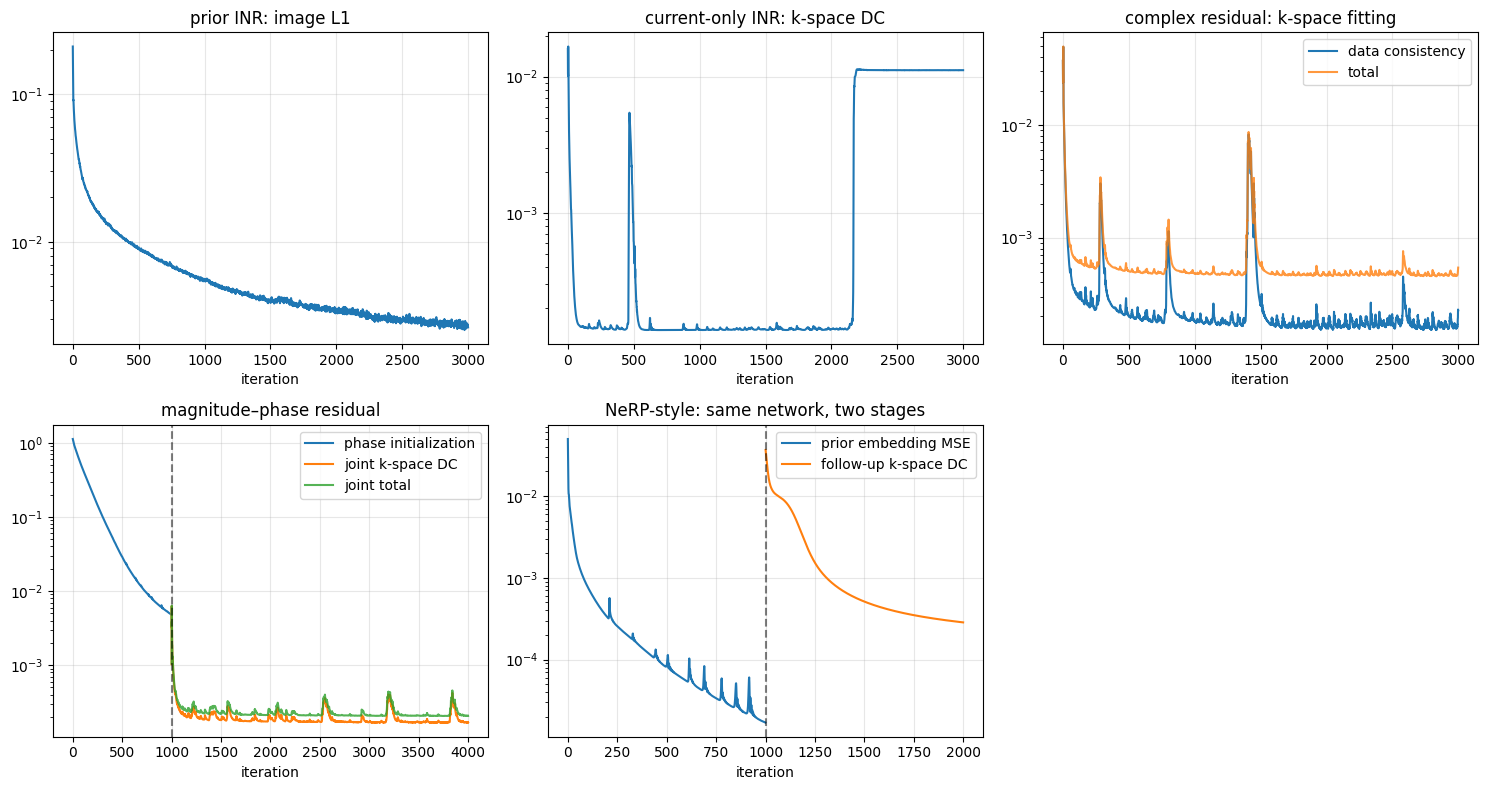

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.reshape(-1)
axes[0].plot(prior_history['loss'])
axes[0].set_title('prior INR: image L1')
if current_only_result is not None:
    axes[1].plot(current_only_result.history['dc'])
    axes[1].set_title('current-only INR: k-space DC')
else:
    axes[1].axis('off')
axes[2].plot(residual_result.history['dc'], label='data consistency')
axes[2].plot(residual_result.history['loss'], label='total', alpha=0.8)
axes[2].set_title('complex residual: k-space fitting')
axes[2].legend()
if magnitude_phase_result is not None:
    axes[3].plot(phase_init_history['loss'], label='phase initialization')
    offset = len(phase_init_history['loss'])
    axes[3].plot(
        np.arange(offset, offset + len(magnitude_phase_result.history['dc'])),
        magnitude_phase_result.history['dc'], label='joint k-space DC',
    )
    axes[3].plot(
        np.arange(offset, offset + len(magnitude_phase_result.history['loss'])),
        magnitude_phase_result.history['loss'], label='joint total', alpha=0.8,
    )
    axes[3].axvline(offset, color='black', linestyle='--', alpha=0.5)
    axes[3].set_title('magnitude–phase residual')
    axes[3].legend()
else:
    axes[3].axis('off')
if RUN_NERP:
    axes[4].plot(nerp_prior_history, label='prior embedding MSE')
    offset = len(nerp_prior_history)
    axes[4].plot(
        np.arange(offset, offset + len(nerp_kspace_history)),
        nerp_kspace_history,
        label='follow-up k-space DC',
    )
    axes[4].axvline(offset, color='black', linestyle='--', alpha=0.5)
    axes[4].set_title('NeRP-style: same network, two stages')
    axes[4].legend()
else:
    axes[4].axis('off')
axes[5].axis('off')
for ax in axes[:5]:
    if ax.axison:
        ax.set_yscale('log')
        ax.set_xlabel('iteration')
        ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Reading the result

The quick setting is a pipeline check, not a scientific comparison. Before drawing conclusions, set `QUICK_RUN = False`, repeat several seeds/slices, and match model capacity and optimization effort. The most informative comparison is not just PSNR: inspect whether each method reconstructs the signed true-change map instead of remaining close to the prior.

First compare both prior-informed variants with current-only INR: if they do not improve on it, the prior is not adding value under this slice and mask. Then compare complex residual with magnitude–phase residual. A magnitude–phase improvement, together with a sparser scalar $\Delta m$, supports the hypothesis that phase should not be forced into the longitudinal residual. NeRP-style remains a deliberately naive real/imaginary adaptation here because its DICOM magnitude embedding starts with zero phase.